In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("water_potability.csv")

In [2]:
df.shape

(3276, 10)

*Data Understanding and EDA*

In [3]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
import seaborn as sns

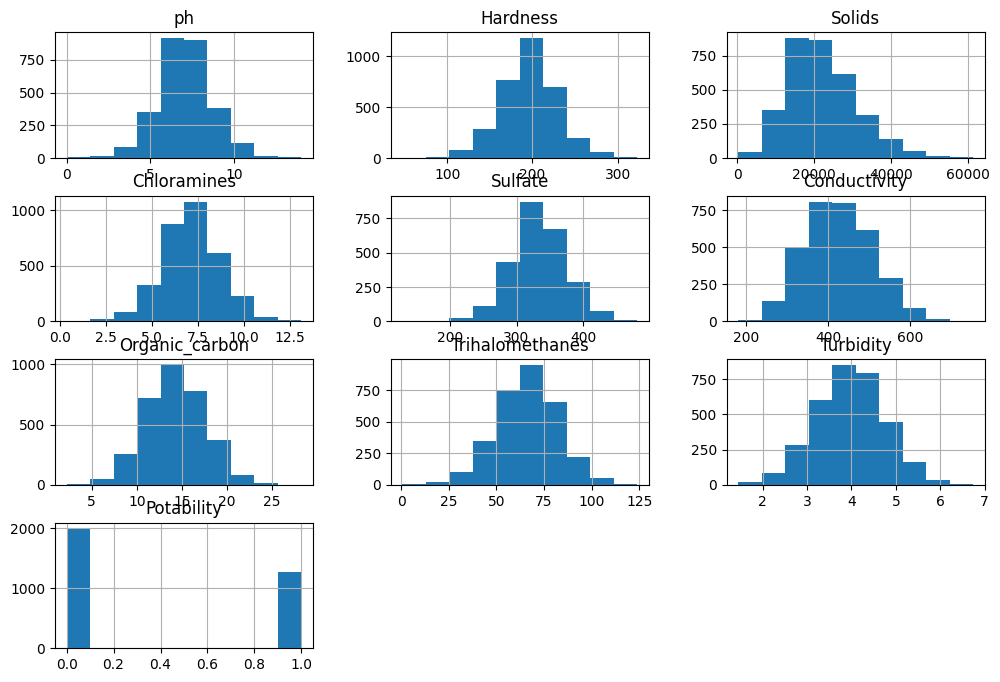

In [7]:
df.hist(figsize=(12, 8))
plt.show()

Checking missing values based of percentage

In [8]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [9]:
df.isnull().sum()/len(df)*100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [10]:
df.dropna(inplace=True)

In [11]:
df.Potability.value_counts()

Potability
0    1200
1     811
Name: count, dtype: int64

In [12]:
potable=df[df["Potability"]==1]
notpotable=df[df["Potability"]==0]

Importing resampler

In [13]:
from sklearn.utils import resample
df_minority_upsampled = resample(potable, replace = True, n_samples = 1200) 

In [14]:
from sklearn.utils import shuffle
df = pd.concat([notpotable, df_minority_upsampled])
df = shuffle(df) 

df.shape
df.Potability.value_counts()

Potability
0    1200
1    1200
Name: count, dtype: int64

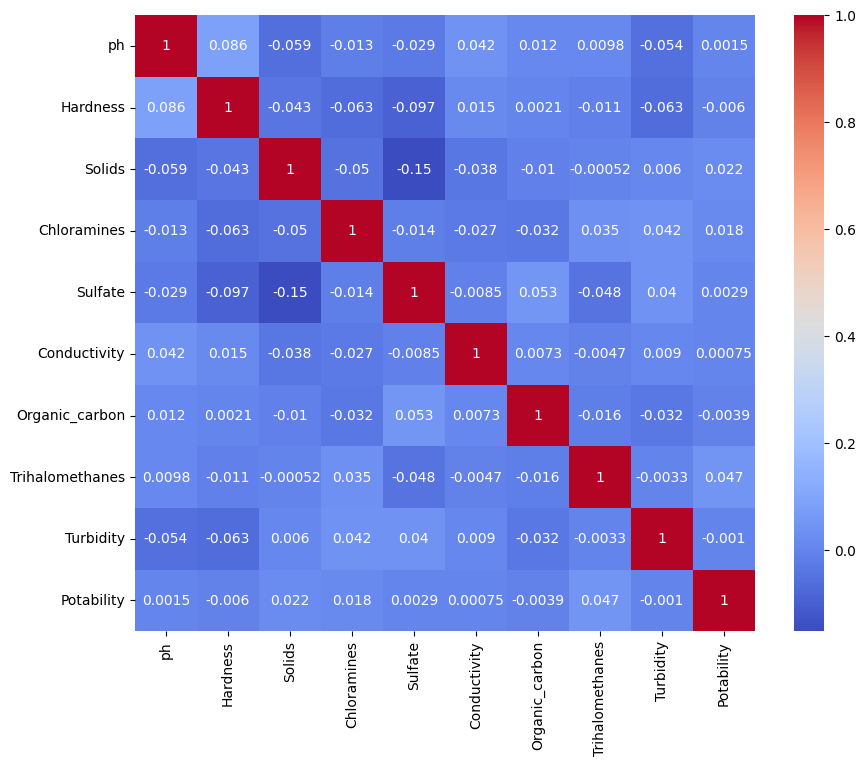

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [28]:
corr = df.corr()
corr["Potability"].sort_values(ascending=False)*100

Potability         100.000000
Trihalomethanes      4.674333
Solids               2.218988
Chloramines          1.845125
Sulfate              0.286048
ph                   0.146098
Conductivity         0.075398
Turbidity           -0.102247
Organic_carbon      -0.386375
Hardness            -0.604422
Name: Potability, dtype: float64

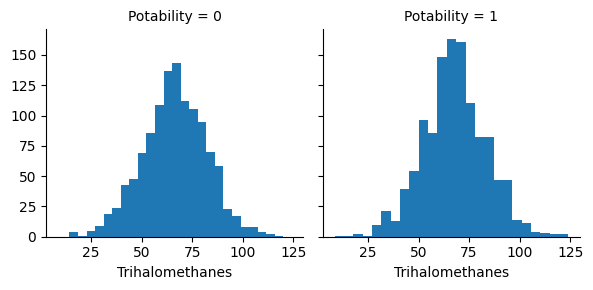

In [30]:
g = sns.FacetGrid(df,col="Potability")
g.map(plt.hist,"Trihalomethanes",bins=25)

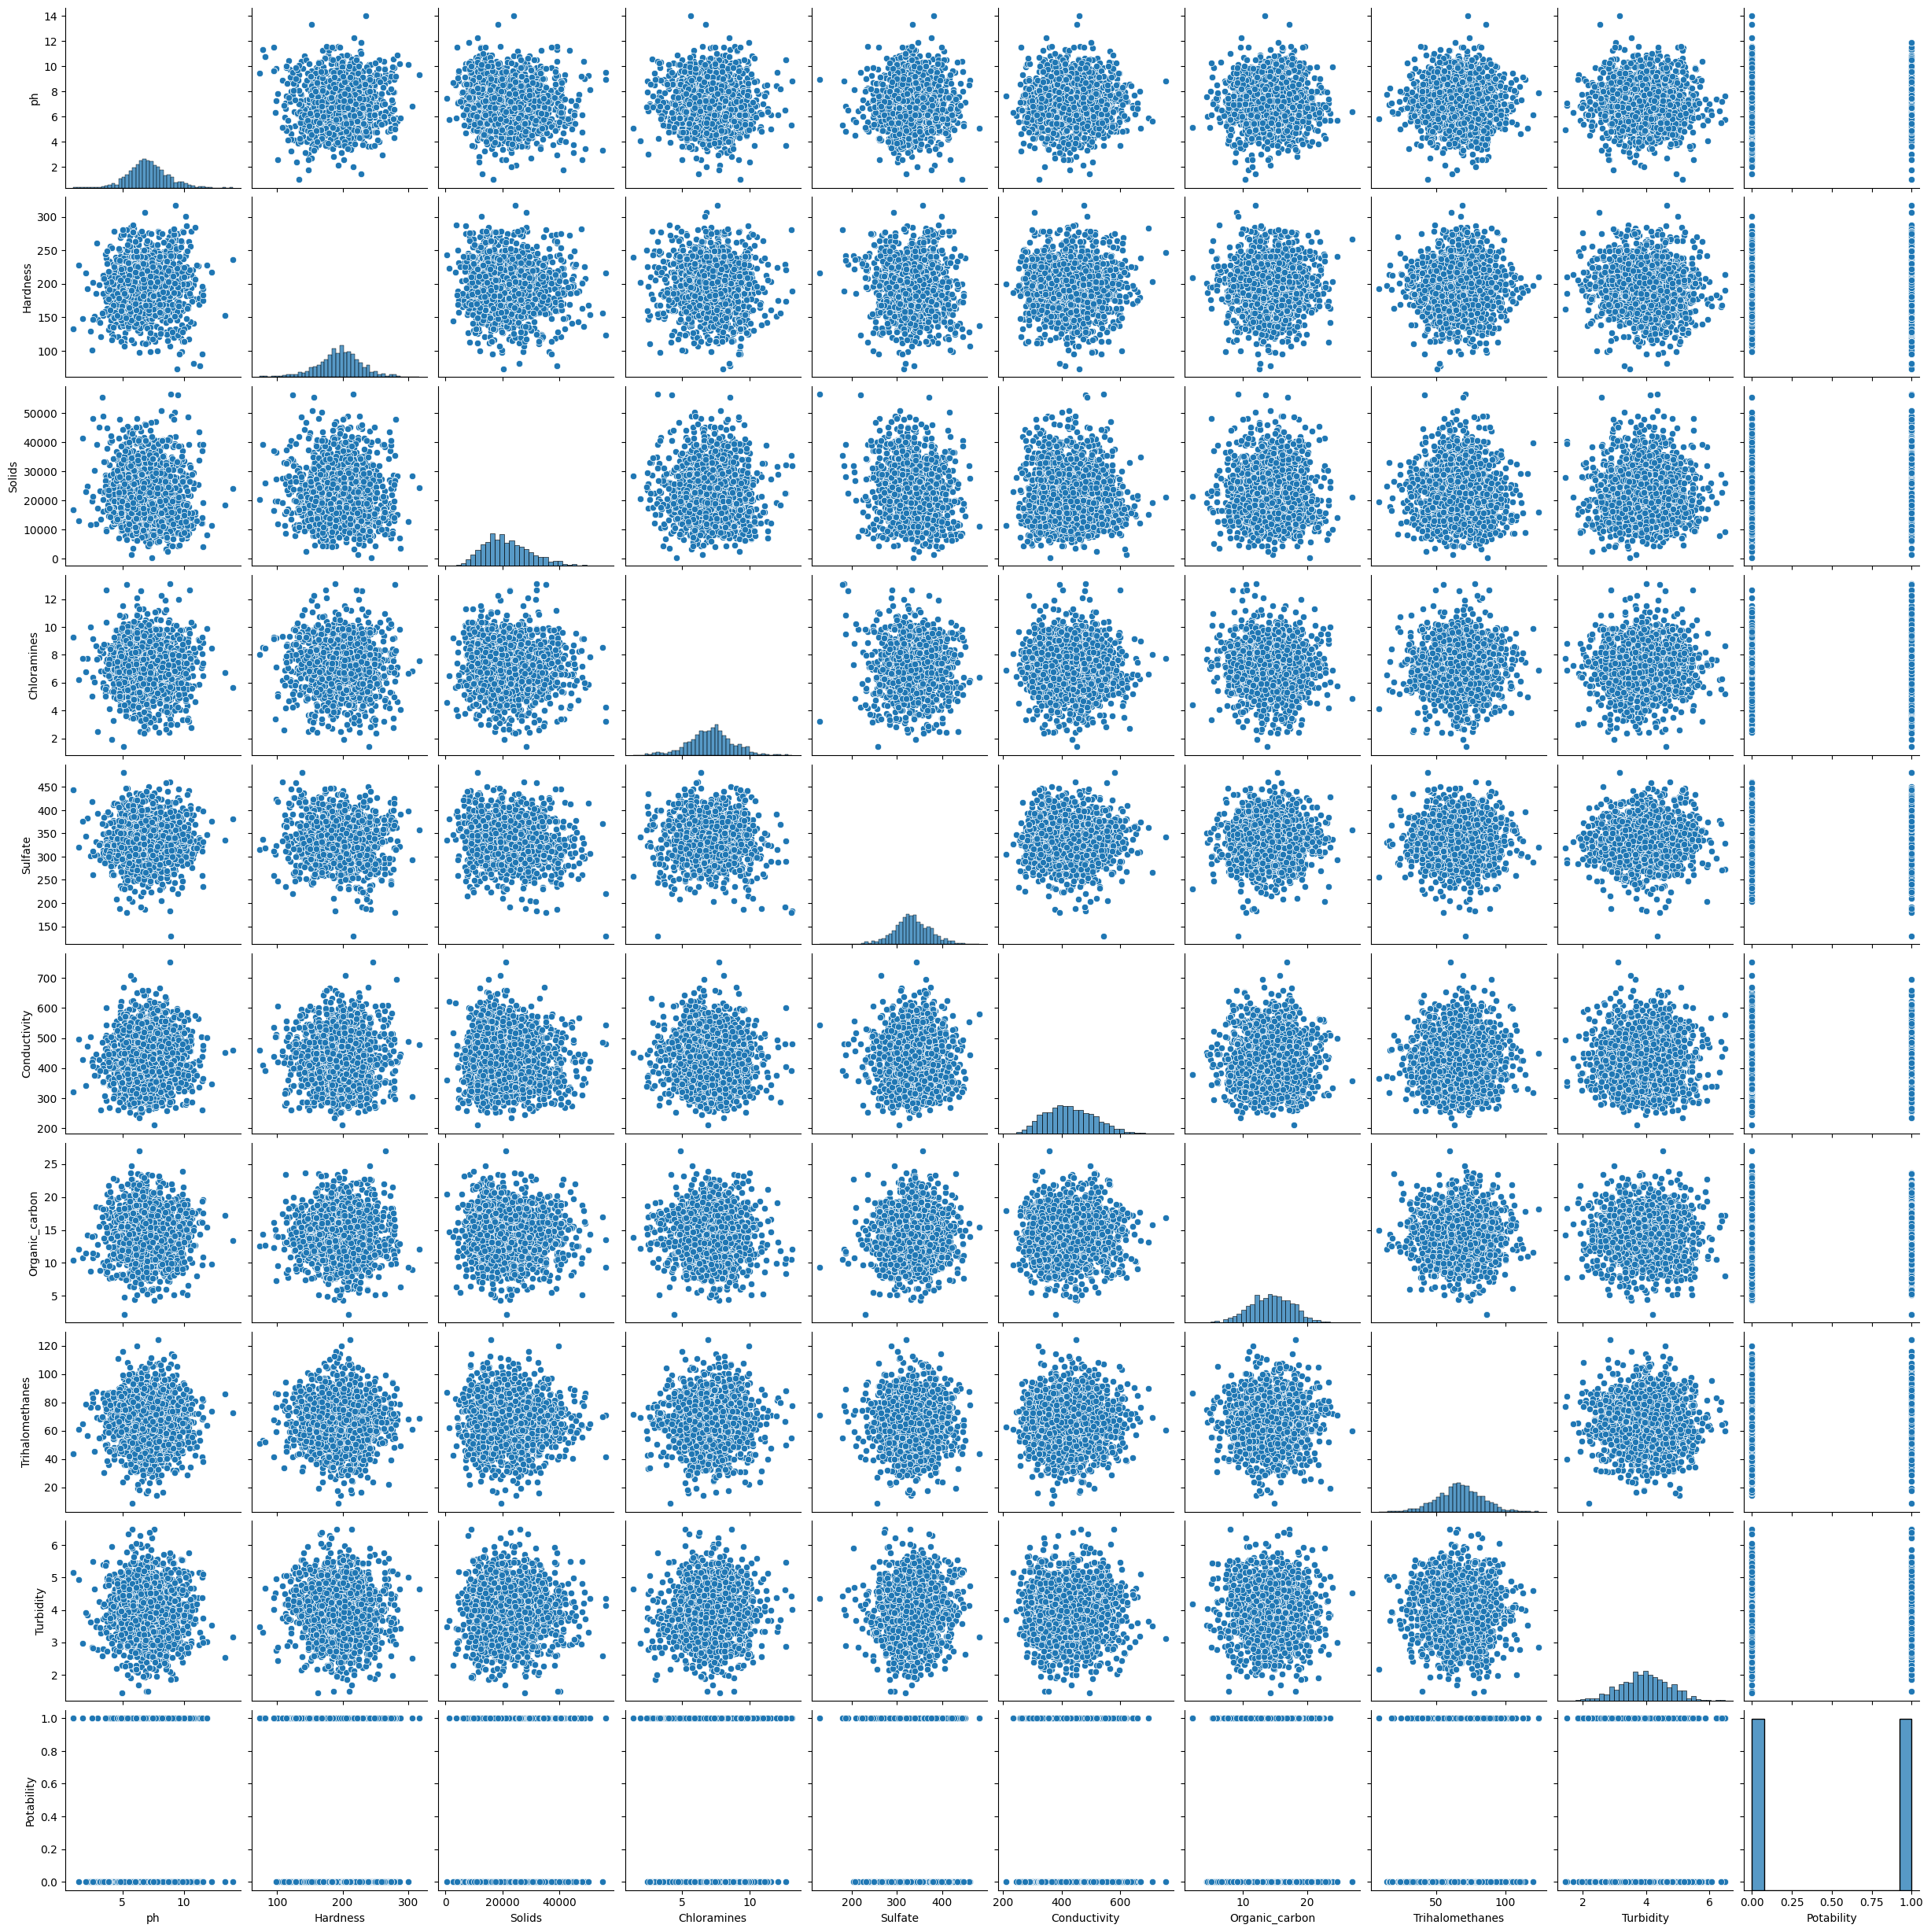

In [31]:
sns.pairplot(df[['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']])

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
X = df.drop(["Potability"],axis=1)
y = df["Potability"]

In [21]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
col= X.columns
X[col] = st.fit_transform(X[col])
X[col]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
1870,-0.318910,0.661205,0.312757,-0.800615,-0.563098,0.597923,-0.888062,-1.167225,-0.570927
2350,-1.290829,1.336825,0.771962,-3.538727,-1.828265,0.302251,-0.165409,0.284047,0.879348
2396,0.422926,0.482971,-0.049026,-0.091988,-1.573706,0.836102,-0.886105,1.139856,1.306233
1033,0.443726,0.092303,-0.337931,0.146968,-0.413103,-0.724874,-1.324162,-0.111668,-1.053457
489,-0.912722,-0.335582,-0.503778,-1.122315,0.125952,-0.222024,0.243172,-2.217120,-0.883670
...,...,...,...,...,...,...,...,...,...
378,-0.629714,1.622882,2.751781,0.142951,0.119038,-1.379048,-0.942931,1.367781,-1.097087
1257,-1.021980,-0.952729,-1.158781,-0.207083,-0.767761,1.345663,0.001945,0.184669,0.905937
3209,-1.444261,0.809140,-0.722146,0.470217,-0.326455,-0.120115,0.343767,1.087850,0.015700
1353,2.916060,-0.381823,-2.079306,0.172149,1.578032,0.583192,-1.066821,0.151814,-1.229817


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)


In [33]:
model = RandomForestClassifier(max_depth=15)
model.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [34]:
y_pred = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       239
           1       0.84      0.85      0.85       241

    accuracy                           0.85       480
   macro avg       0.85      0.85      0.85       480
weighted avg       0.85      0.85      0.85       480



<Axes: >

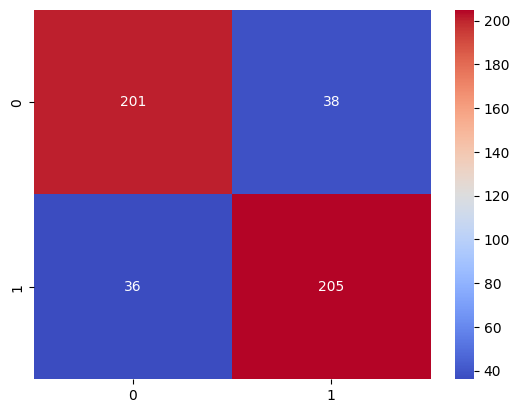

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test,y_pred)

print(classification_report(y_test,y_pred))


sns.heatmap(cm,annot=True,fmt="d",cmap="coolwarm")

In [35]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9973958333333334
Testing Accuracy: 0.8541666666666666
